In [1]:
import pandas as pd
import numpy as np
from functions.running import prepare_data
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.decomposition import PCA
from functions.training import train
from functions.networks import SimpleNN, FullNN

In [2]:
df_train = pd.read_table('https://archive.ics.uci.edu/ml/machine-learning-databases/spect/SPECTF.train', header = None,sep=',')
df_test = pd.read_table('https://archive.ics.uci.edu/ml/machine-learning-databases/spect/SPECTF.test',
                     header=None, sep = ',')
df = pd.concat([df_train, df_test])
data = df.to_numpy()
X,y = data[:,1:], data[:,0]
G = len(np.unique(y))
for g in range(G):
  print(sum(y==g))
X = X.astype('float')

55
212


In [3]:
dataname = 'heart'
input_dim = X.shape[1]
epochs = 200
batch_size = 64
n_layer = 5
init_type = 'he'
dataname_ = dataname + str(n_layer) + init_type
missing = False

X_train, X_test, y_train, y_test = prepare_data(X,y, missing = missing)
input_dim = X_train.shape[1]  # Number of features

output_dim = len(np.unique(y_train))  # Number of classes (for Iris dataset)
variance_retained = .95
pca = PCA(n_components=variance_retained)
pca.fit(X_train)
n_components = pca.n_components_
print(n_components)
hidden_dim = n_components  # Hidden layer size

other_layers = SimpleNN(input_dim=n_components, hidden_dim=hidden_dim, output_dim=output_dim, n_layer = n_layer, init_type = init_type)

train_loader = torch.utils.data.DataLoader(list(zip(X_train, y_train)), batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(list(zip(X_test, y_test)), batch_size=batch_size, shuffle=False)

criterion = nn.CrossEntropyLoss()
learning_rate = 0.01

relu_nn =  FullNN(input_dim, n_components, other_layers, activation='none', init_type=init_type)
optimizer = optim.Adam(relu_nn.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss()
nn_model, train_losses_fnn, test_accuracies_fnn, training_time_fnn, _ = train(relu_nn, train_loader, test_loader, criterion, optimizer, epochs=epochs)

23
Epoch 1/200, Training Loss: 0.5082, Testing Accuracy: 0.8148, Training Time: 0.0122
Epoch 2/200, Training Loss: 0.4039, Testing Accuracy: 0.8148, Training Time: 0.0198
Epoch 3/200, Training Loss: 0.3664, Testing Accuracy: 0.8025, Training Time: 0.0310
Epoch 4/200, Training Loss: 0.3121, Testing Accuracy: 0.8025, Training Time: 0.0374
Epoch 5/200, Training Loss: 0.2760, Testing Accuracy: 0.7901, Training Time: 0.0453
Epoch 6/200, Training Loss: 0.2268, Testing Accuracy: 0.8025, Training Time: 0.0525
Epoch 7/200, Training Loss: 0.1714, Testing Accuracy: 0.8025, Training Time: 0.0598
Epoch 8/200, Training Loss: 0.1312, Testing Accuracy: 0.7778, Training Time: 0.0669
Epoch 9/200, Training Loss: 0.1002, Testing Accuracy: 0.7901, Training Time: 0.0748
Epoch 10/200, Training Loss: 0.0788, Testing Accuracy: 0.7778, Training Time: 0.0814
Epoch 11/200, Training Loss: 0.0467, Testing Accuracy: 0.8148, Training Time: 0.0887
Epoch 12/200, Training Loss: 0.0380, Testing Accuracy: 0.8519, Training

In [4]:
import shap
# ====== Interpret NN======

print("\n=== SHAP NN ===")
background_np = X_train.numpy()
test_np = X_test.numpy()

def nn_torch_predict(x_numpy):
    x_torch = torch.tensor(x_numpy, dtype=torch.float32)
    with torch.no_grad():
        return nn_model(x_torch).numpy()
#np.random.seed(16) 
nn_explainer = shap.KernelExplainer(nn_torch_predict, background_np)
nn_shap_values = nn_explainer.shap_values(test_np)

Using 186 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.



=== SHAP NN ===


  0%|          | 0/81 [00:00<?, ?it/s]

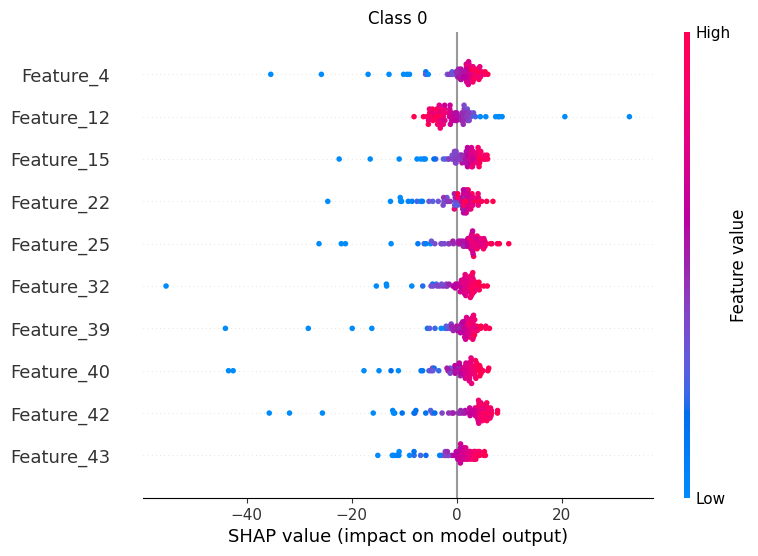

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import shap

# Mean absolute SHAP value across samples for Class 0
nn_importance_class0 = np.mean(np.abs(nn_shap_values[:, :, 0]), axis=0)

# Get indices of top 10 features
top10_idx_class0 = np.array(sorted(set(np.argsort(nn_importance_class0)[-10:])))

# Feature names in the exact order we want
nn_feature_names_class0 = [f'Feature_{i+1}' for i in top10_idx_class0]

# Create figure and axis
fig, ax = plt.subplots(1, 1, figsize=(14, 6))

# Plot with fixed order
shap.summary_plot(
    nn_shap_values[:, top10_idx_class0, 0],
    test_np[:, top10_idx_class0],
    feature_names=nn_feature_names_class0,
    show=False,
    sort=False,   # <-- this is key
)

# Title
ax.set_title('Class 0')

# Colorbar label
cbar = fig.axes[-1]
cbar.set_ylabel("Feature value")
plt.savefig("plots/NN_feature_global_class0.pdf", format="pdf", bbox_inches="tight")

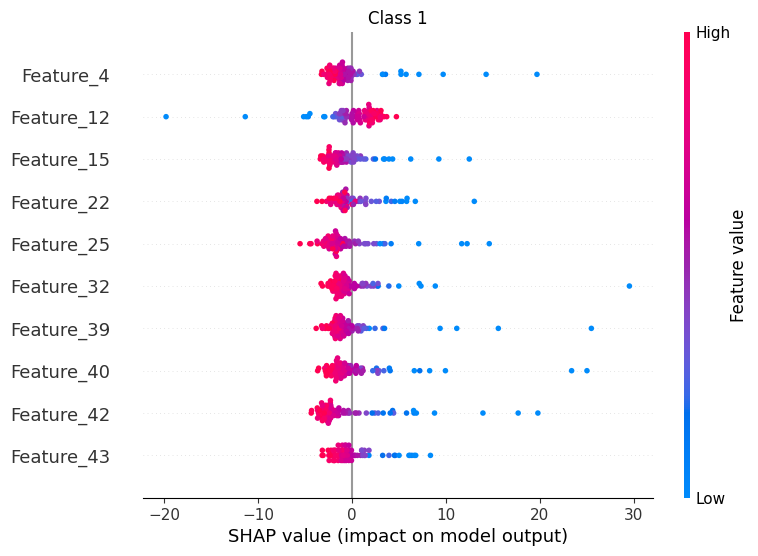

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import shap

# Mean absolute SHAP value across samples for Class 1
nn_importance_class1 = np.mean(np.abs(nn_shap_values[:, :, 1]), axis=0)

# Get indices of top 10 features
#top10_idx_class0 = np.array(sorted(set(np.argsort(pcsinit_importance_class0)[-10:])))

# Feature names in the exact order we want
#pcsinit_feature_names_class0 = [f'Feature_{i+1}' for i in top10_idx_class0]

# Create figure and axis
fig, ax = plt.subplots(1, 1, figsize=(14, 6))

# Plot with fixed order
shap.summary_plot(
    nn_shap_values[:, top10_idx_class0, 1],
    test_np[:, top10_idx_class0],
    feature_names=nn_feature_names_class0,
    show=False,
    sort=False,   # <-- this is key
)

# Title
ax.set_title('Class 1')

# Colorbar label
cbar = fig.axes[-1]
cbar.set_ylabel("Feature value")
plt.savefig("plots/NN_feature_global_class1.pdf", format="pdf", bbox_inches="tight")